# 03. Virulence Factor Analysis

Reproduces and extends the virulence factor analysis from Lee et al. (2023).

**Analysis sections:**
1. Virulence factor heatmap — Figure 3 reproduction (seaborn + UPGMA dendrogram)
2. Interactive heatmap (Plotly) — hover to inspect per-strain profiles
3. Virulence score per strain — overall burden analysis
4. Category-level prevalence — which VF categories dominate?
5. **Extended: Species-level virulence profile comparison**

**Reference:** Lee et al. (2023), *Frontiers in Microbiology*, 14:1175304  
**Data:** VFDB analysis results (VFanalyzer), UPGMA tree from ANI analysis

In [1]:
# ── dependencies ──────────────────────────────────────────────
# pip install pandas numpy seaborn matplotlib plotly scipy

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from scipy.cluster.hierarchy import dendrogram, linkage, to_tree
from io import StringIO
from pathlib import Path
import re

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load data

In [2]:
# ── VF heatmap matrix (29 strains × 18 VF categories) ─────────
vf = pd.read_excel(RAW / 'VF_profile_heatmap.xlsx',
                   sheet_name='Sheet1', index_col=0)
print(f'VF matrix: {vf.shape}')   # (29, 18)

# ── species annotation ────────────────────────────────────────
species_map = {
    'LJP308'                : 'A. piscicola',
    'A.piscicola_LMG_24783' : 'A. piscicola',
    'SU58-3'                : 'A. bestiarum',
    'SU6'                   : 'A. bestiarum',
    'SL22'                  : 'A. bestiarum',
    'A.bestiarum GA97_22'   : 'A. bestiarum',
    'OY59'                  : 'A. salmonicida',
    'SU2'                   : 'A. salmonicida',
    'OY56'                  : 'A. salmonicida',
    'SL21'                  : 'A. salmonicida',
    'LJP441'                : 'A. salmonicida',
    'SC45'                  : 'A. salmonicida',
    'SL19'                  : 'A. salmonicida',
    'A.salmonicida_O23A'    : 'A. salmonicida',
    'SU4'                   : 'A. caviae',
    'A.caviae_1605_27183'   : 'A. caviae',
    'A537'                  : 'A. hydrophila',
    'A.hydrophila_AH10'     : 'A. hydrophila',
    'A.dhakensis_Aer_OnlF1' : 'A. dhakensis',
    'A536'                  : 'A. dhakensis',
    'A533'                  : 'A. dhakensis',
    'OY52'                  : 'A. media',
    'A.media_R1_18'         : 'A. media',
    'SC42'                  : 'A. rivipollensis',
    'OY1'                   : 'A. rivipollensis',
    'A539'                  : 'A. rivipollensis',
    'SU9'                   : 'A. rivipollensis',
    'SU3'                   : 'A. rivipollensis',
    'SU15'                  : 'A. rivipollensis',
}

# ── VF category → functional group (from R script) ────────────
category_group = {
    'Msh type IV pili' : 'Adherence',
    'Tap type IV pili' : 'Adherence',
    'Flp type IV'      : 'Adherence',
    'Lateral flagella' : 'Motility',
    'Polar flagella'   : 'Motility',
    'T2SS'             : 'Secretion',
    'T3SS'             : 'Secretion',
    'T6SS'             : 'Secretion',
    'aerA/act'         : 'Toxin',
    'ast'              : 'Toxin',
    'ahh1'             : 'Toxin',
    'hlyA'             : 'Toxin',
    'hemIII'           : 'Toxin',
    'th'               : 'Toxin',
    'RTX'              : 'Toxin',
    'toxA'             : 'Toxin',
    'capsule'          : 'Immune evasion',
    'O-antigen'        : 'Immune evasion',
}

# ── color palettes ────────────────────────────────────────────
species_palette = {
    'A. salmonicida'   : '#E07B54',
    'A. piscicola'     : '#5B8DB8',
    'A. bestiarum'     : '#6BAF92',
    'A. media'         : '#9B7BB8',
    'A. rivipollensis' : '#D4A843',
    'A. caviae'        : '#C4706A',
    'A. hydrophila'    : '#7BA87B',
    'A. dhakensis'     : '#8AA6C4',
}
group_palette = {
    'Adherence'     : '#4CAF50',
    'Motility'      : '#FFC107',
    'Secretion'     : '#9E9E9E',
    'Toxin'         : '#F44336',
    'Immune evasion': '#2196F3',
}

# row colors (species) and col colors (functional group)
row_colors = pd.Series(
    [species_palette.get(species_map.get(s, ''), '#DDDDDD') for s in vf.index],
    index=vf.index, name='Species'
)
col_colors = pd.Series(
    [group_palette.get(category_group.get(c, ''), '#DDDDDD') for c in vf.columns],
    index=vf.columns, name='Function'
)

print('Data loaded — 29 strains, 18 VF categories')
print(f'Value range: {vf.values.min()} – {vf.values.max()}')

VF matrix: (29, 18)
Data loaded — 29 strains, 18 VF categories
Value range: 0 – 1


---
## 2. Figure 3 reproduction — VF heatmap with dendrogram

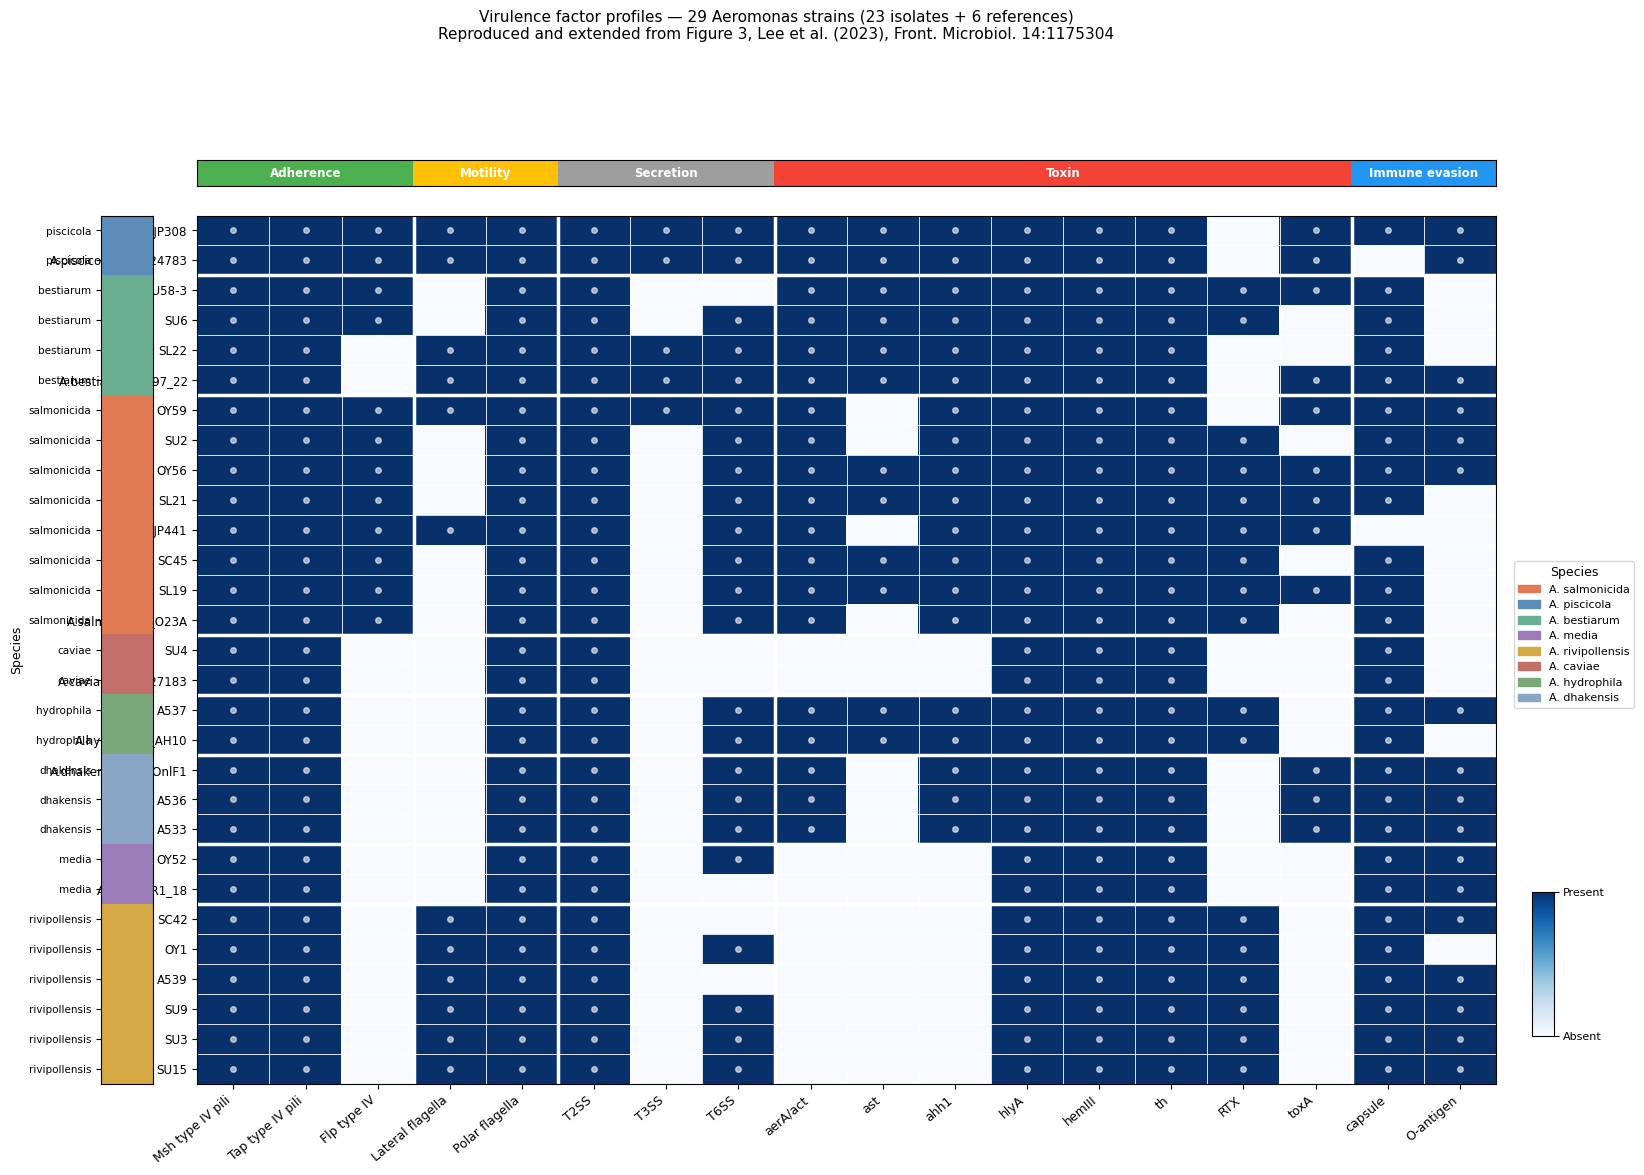

Saved: fig3_virulence_heatmap.png


In [5]:
# ── Figure 3 reproduction — redesigned for clarity ──────────
# Key design changes from original:
#   1. Larger figure, species grouped visually
#   2. Annotation text in cells for clear presence/absence
#   3. White = absent, dark blue = present (high contrast)
#   4. Species color bar wider + labeled
#   5. Column group dividers clearly marked

from scipy.cluster.hierarchy import linkage
import matplotlib.patches as mpatches

# sort rows by species (matches paper's visual grouping)
species_order_fig = [
    'A. piscicola', 'A. bestiarum', 'A. salmonicida',
    'A. caviae', 'A. hydrophila', 'A. dhakensis',
    'A. media', 'A. rivipollensis'
]
vf_sorted = vf.copy()
vf_sorted['_species'] = [species_map.get(s, 'z') for s in vf_sorted.index]
vf_sorted['_sp_rank'] = vf_sorted['_species'].map(
    {s: i for i, s in enumerate(species_order_fig)}
).fillna(99)
vf_sorted = vf_sorted.sort_values('_sp_rank').drop(columns=['_species', '_sp_rank'])

# figure layout: main heatmap + left species bar + top group bar
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(
    3, 3,
    width_ratios=[0.04, 0.02, 1],
    height_ratios=[0.03, 0.02, 1],
    hspace=0.02, wspace=0.02
)
ax_main  = fig.add_subplot(gs[2, 2])   # main heatmap
ax_left  = fig.add_subplot(gs[2, 0])   # species color bar
ax_top   = fig.add_subplot(gs[0, 2])   # VF group color bar

strains = vf_sorted.index.tolist()
vf_cats = vf_sorted.columns.tolist()
z = vf_sorted.values.astype(float)
n_strains, n_cats = z.shape

# ── main heatmap ──────────────────────────────────────────────
im = ax_main.imshow(
    z, aspect='auto', cmap='Blues', vmin=0, vmax=1,
    interpolation='nearest'
)

# cell annotations: dot for present, nothing for absent
for i in range(n_strains):
    for j in range(n_cats):
        if z[i, j] == 1:
            ax_main.plot(j, i, 'o', color='white', markersize=4,
                        markerfacecolor='white', alpha=0.6)

# grid lines
ax_main.set_xticks(np.arange(-0.5, n_cats, 1), minor=True)
ax_main.set_yticks(np.arange(-0.5, n_strains, 1), minor=True)
ax_main.grid(which='minor', color='white', linewidth=0.6)
ax_main.tick_params(which='minor', size=0)

# species group dividers (horizontal lines between species)
prev_sp = None
for i, s in enumerate(strains):
    sp = species_map.get(s, '')
    if sp != prev_sp and i > 0:
        ax_main.axhline(i - 0.5, color='white', linewidth=2.5)
    prev_sp = sp

# VF group dividers (vertical lines between functional groups)
prev_grp = None
for j, cat in enumerate(vf_cats):
    grp = category_group.get(cat, '')
    if grp != prev_grp and j > 0:
        ax_main.axvline(j - 0.5, color='white', linewidth=2.5)
    prev_grp = grp

# axis labels
ax_main.set_xticks(range(n_cats))
ax_main.set_xticklabels(vf_cats, rotation=40, ha='right', fontsize=9)
ax_main.set_yticks(range(n_strains))
ax_main.set_yticklabels(strains, fontsize=8.5)
ax_main.xaxis.set_tick_params(labeltop=False, labelbottom=True)

# ── left: species color bar ───────────────────────────────────
sp_colors_sorted = [
    species_palette.get(species_map.get(s, ''), '#DDDDDD')
    for s in strains
]
sp_array = np.array([[plt.matplotlib.colors.to_rgba(c)]
                      for c in sp_colors_sorted])
ax_left.imshow(sp_array, aspect='auto', interpolation='nearest')
ax_left.set_xticks([])
ax_left.set_yticks(range(n_strains))
ax_left.set_yticklabels(
    [species_map.get(s,'').replace('A. ','') for s in strains],
    fontsize=7.5
)
ax_left.set_ylabel('Species', fontsize=9, labelpad=4)

# ── top: VF functional group color bar ────────────────────────
grp_colors_sorted = [
    group_palette.get(category_group.get(c, ''), '#DDDDDD')
    for c in vf_cats
]
grp_array = np.array([[
    plt.matplotlib.colors.to_rgba(c) for c in grp_colors_sorted
]])
ax_top.imshow(grp_array, aspect='auto', interpolation='nearest')
ax_top.set_yticks([])
ax_top.set_xticks([])

# group labels in top bar
grp_positions = {}
prev_grp = None
start = 0
for j, cat in enumerate(vf_cats):
    grp = category_group.get(cat, '')
    if grp != prev_grp:
        if prev_grp:
            grp_positions[prev_grp] = (start + j - 1) / 2
        start = j
        prev_grp = grp
grp_positions[prev_grp] = (start + n_cats - 1) / 2

for grp_name, pos in grp_positions.items():
    ax_top.text(pos, 0, grp_name, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='white')

# ── legends ───────────────────────────────────────────────────
sp_handles = [mpatches.Patch(color=c, label=s)
              for s, c in species_palette.items()]
fig.legend(
    handles=sp_handles, title='Species',
    bbox_to_anchor=(0.98, 0.55), loc='upper right',
    fontsize=8, title_fontsize=9, frameon=True,
    ncol=1
)

# colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.012, 0.12])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Absent', 'Present'], fontsize=8)

fig.suptitle(
    'Virulence factor profiles — 29 Aeromonas strains (23 isolates + 6 references)\n'
    'Reproduced and extended from Figure 3, Lee et al. (2023), Front. Microbiol. 14:1175304',
    fontsize=11, y=1.005
)

plt.savefig(PROC / 'fig3_virulence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_virulence_heatmap.png')


---
## 3. Interactive VF heatmap (Plotly)

In [6]:
# ── interactive heatmap — species-sorted, hover per cell ─────
# uses vf_sorted (species-grouped order from cell 5)

strains  = vf_sorted.index.tolist()
vf_cats  = vf_sorted.columns.tolist()
z_vals   = vf_sorted.values.astype(float)

# hover text
hover_text = []
for i, strain in enumerate(strains):
    row_hover = []
    sp = species_map.get(strain, 'Unknown')
    for j, cat in enumerate(vf_cats):
        present = 'Present' if z_vals[i, j] == 1 else 'Absent'
        grp = category_group.get(cat, '')
        row_hover.append(
            f'<b>{strain}</b><br>'
            f'Species: {sp}<br>'
            f'VF: <b>{cat}</b> ({grp})<br>'
            f'Status: <b>{present}</b>'
        )
    hover_text.append(row_hover)

# species color annotations for y-axis
sp_label_colors = [
    species_palette.get(species_map.get(s, ''), '#333333')
    for s in strains
]

fig = go.Figure(data=go.Heatmap(
    z=z_vals,
    x=vf_cats,
    y=strains,
    colorscale=[[0, '#F7FBFF'], [1, '#1565C0']],
    zmin=0, zmax=1,
    text=hover_text,
    hoverinfo='text',
    showscale=True,
    colorbar=dict(
        tickvals=[0, 1],
        ticktext=['Absent', 'Present'],
        thickness=12, len=0.3, y=0.15
    )
))

# functional group dividers (vertical)
shapes = []
prev = None
for j, cat in enumerate(vf_cats):
    grp = category_group.get(cat, '')
    if grp != prev and prev is not None:
        shapes.append(dict(
            type='line', x0=j-0.5, x1=j-0.5,
            y0=-0.5, y1=len(strains)-0.5,
            line=dict(color='white', width=3)
        ))
    prev = grp

# species group dividers (horizontal)
prev_sp = None
for i, s in enumerate(strains):
    sp = species_map.get(s, '')
    if sp != prev_sp and i > 0:
        shapes.append(dict(
            type='line', x0=-0.5, x1=len(vf_cats)-0.5,
            y0=i-0.5, y1=i-0.5,
            line=dict(color='white', width=2.5)
        ))
    prev_sp = sp

# group label annotations on top
annotations = []
prev_grp = None
start = 0
for j, cat in enumerate(vf_cats):
    grp = category_group.get(cat, '')
    if grp != prev_grp:
        if prev_grp:
            mid = (start + j - 1) / 2
            annotations.append(dict(
                x=mid, y=len(strains) + 0.8,
                text=f'<b>{prev_grp}</b>',
                showarrow=False,
                font=dict(size=10, color=group_palette.get(prev_grp, '#333')),
                xref='x', yref='y'
            ))
        start = j
        prev_grp = grp
# last group
mid = (start + len(vf_cats) - 1) / 2
annotations.append(dict(
    x=mid, y=len(strains) + 0.8,
    text=f'<b>{prev_grp}</b>',
    showarrow=False,
    font=dict(size=10, color=group_palette.get(prev_grp, '#333')),
    xref='x', yref='y'
))

fig.update_layout(
    title=dict(
        text='Virulence factor profiles — 29 Aeromonas strains<br>'
             '<sup>Hover to inspect per-strain VF status | '
             'Strains grouped by species | White lines = group boundaries</sup>',
        font_size=13
    ),
    width=1000, height=820,
    xaxis=dict(tickangle=40, tickfont=dict(size=9), side='bottom'),
    yaxis=dict(tickfont=dict(size=8.5), autorange='reversed'),
    shapes=shapes,
    annotations=annotations,
    margin=dict(l=180, b=160, r=80, t=100)
)

fig.show()


---
## 4. Virulence score per strain

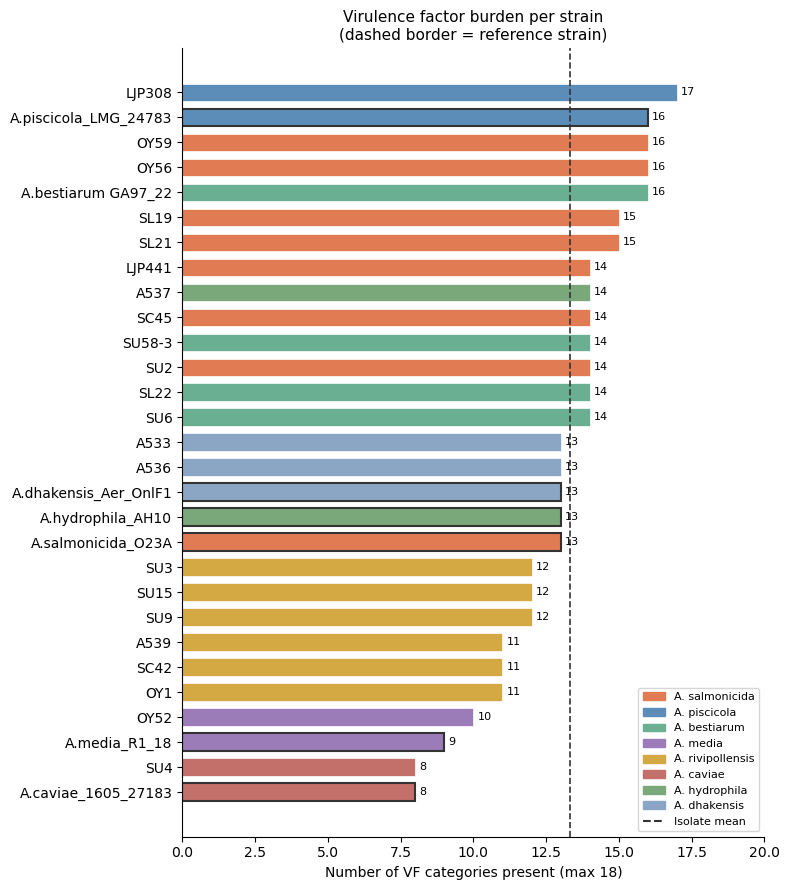

Saved: fig_virulence_scores.png


In [7]:
# ── total VF score = sum of present categories (0–18) ─────────
vf_score = vf.sum(axis=1).rename('vf_score')
vf_score_df = pd.DataFrame({
    'strain'  : vf_score.index,
    'species' : [species_map.get(s, 'Unknown') for s in vf_score.index],
    'vf_score': vf_score.values,
    'is_ref'  : ['ref' if any(x in s for x in
                              ['_LMG', '_CECT', '_NCTC', '_ATCC', '_CIP',
                               '_AH10', '_O23A', '_R1_18', '_Aer', '_GA97',
                               '_1605'])
                 else 'isolate' for s in vf_score.index]
})

# sort by score
vf_score_df = vf_score_df.sort_values('vf_score', ascending=True)
vf_score_df.to_csv(PROC / 'virulence_scores.csv', index=False)

# ── plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 9))

colors = [species_palette.get(sp, '#CCCCCC') for sp in vf_score_df['species']]
edgecolors = ['#333333' if r == 'ref' else 'white'
              for r in vf_score_df['is_ref']]
linewidths = [1.5 if r == 'ref' else 0.5 for r in vf_score_df['is_ref']]

bars = ax.barh(
    vf_score_df['strain'], vf_score_df['vf_score'],
    color=colors, edgecolor=edgecolors,
    linewidth=linewidths, height=0.7
)
ax.bar_label(bars, padding=3, fontsize=8)

ax.axvline(vf_score_df[vf_score_df['is_ref']=='isolate']['vf_score'].mean(),
           color='#333333', linestyle='--', linewidth=1.2,
           label=f'Isolate mean ({vf_score_df[vf_score_df["is_ref"]=="isolate"]["vf_score"].mean():.1f})')
ax.set_xlim(0, 20)
ax.set_xlabel('Number of VF categories present (max 18)', fontsize=10)
ax.set_title(
    'Virulence factor burden per strain\n'
    '(dashed border = reference strain)',
    fontsize=11
)

sp_handles = [mpatches.Patch(color=c, label=s)
              for s, c in species_palette.items()
              if s in vf_score_df['species'].values]
sp_handles.append(plt.Line2D([0],[0], color='#333333', linestyle='--',
                              label='Isolate mean'))
ax.legend(handles=sp_handles, fontsize=8, loc='lower right')
sns.despine()

plt.tight_layout()
plt.savefig(PROC / 'fig_virulence_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_virulence_scores.png')

---
## 5. VF category prevalence across all isolates

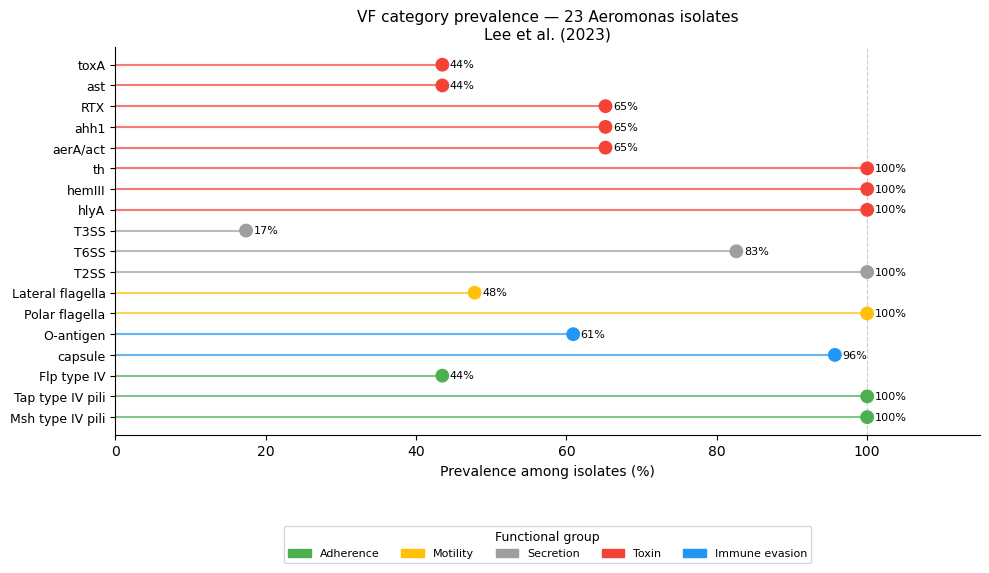

Saved: fig_vf_prevalence.png


In [8]:
# ── isolates only (exclude references) ────────────────────────
ref_strains = [s for s in vf.index
               if any(x in s for x in ['_LMG', '_CECT', '_NCTC', '_ATCC',
                                        '_CIP', '_AH10', '_O23A', '_R1_18',
                                        '_Aer', '_GA97', '_1605'])]
vf_isolates = vf.drop(index=ref_strains)

# prevalence per VF category
prevalence = vf_isolates.mean(axis=0).mul(100).round(1)
prev_df = pd.DataFrame({
    'vf_category': prevalence.index,
    'prevalence' : prevalence.values,
    'group'      : [category_group.get(c, '') for c in prevalence.index]
}).sort_values(['group', 'prevalence'], ascending=[True, False])

# ── lollipop chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = [group_palette.get(g, '#CCCCCC') for g in prev_df['group']]
y_pos = np.arange(len(prev_df))

ax.hlines(y_pos, 0, prev_df['prevalence'], colors=colors,
          linewidth=1.5, alpha=0.7)
ax.scatter(prev_df['prevalence'], y_pos, color=colors, s=80, zorder=5)

# add value labels
for i, (val, y) in enumerate(zip(prev_df['prevalence'], y_pos)):
    ax.text(val + 1, y, f'{val:.0f}%', va='center', fontsize=8)

ax.axvline(100, color='#CCCCCC', linestyle='--', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(prev_df['vf_category'], fontsize=9)
ax.set_xlabel('Prevalence among isolates (%)', fontsize=10)
ax.set_xlim(0, 115)
ax.set_title(
    'VF category prevalence — 23 Aeromonas isolates\n'
    'Lee et al. (2023)',
    fontsize=11
)

grp_handles = [mpatches.Patch(color=c, label=g)
               for g, c in group_palette.items()]
ax.legend(handles=grp_handles, title='Functional group',
          fontsize=8, title_fontsize=9,
          bbox_to_anchor=(0.5, -0.22), loc='upper center', ncol=5)
sns.despine()

plt.tight_layout()
plt.savefig(PROC / 'fig_vf_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_vf_prevalence.png')

---
## 6. Extended: Species-level virulence profile comparison

> *"Overall, strains belonging to A. piscicola, A. bestiarum, A. salmonicida, A. hydrophila,
> and A. dhakensis contained more virulence factors than strains belonging to
> A. caviae, A. media, and A. rivipollensis."*  
> — Lee et al. (2023)

This section quantifies and visualises that statement.

Mean VF presence (%) per species:
                  Msh type IV pili  Tap type IV pili  Flp type IV  Lateral flagella  Polar flagella   T2SS   T3SS   T6SS  aerA/act    ast   ahh1   hlyA  hemIII     th    RTX   toxA  capsule  O-antigen
species                                                                                                                                                                                                 
A. piscicola                 100.0             100.0        100.0             100.0           100.0  100.0  100.0  100.0     100.0  100.0  100.0  100.0   100.0  100.0    0.0  100.0    100.0      100.0
A. salmonicida               100.0             100.0        100.0              28.6           100.0  100.0   14.3  100.0     100.0   57.1  100.0  100.0   100.0  100.0   85.7   71.4     85.7       42.9
A. bestiarum                 100.0             100.0         50.0              50.0           100.0  100.0   50.0   75.0     100.0  100.0  100.0  100.0   100.0  1

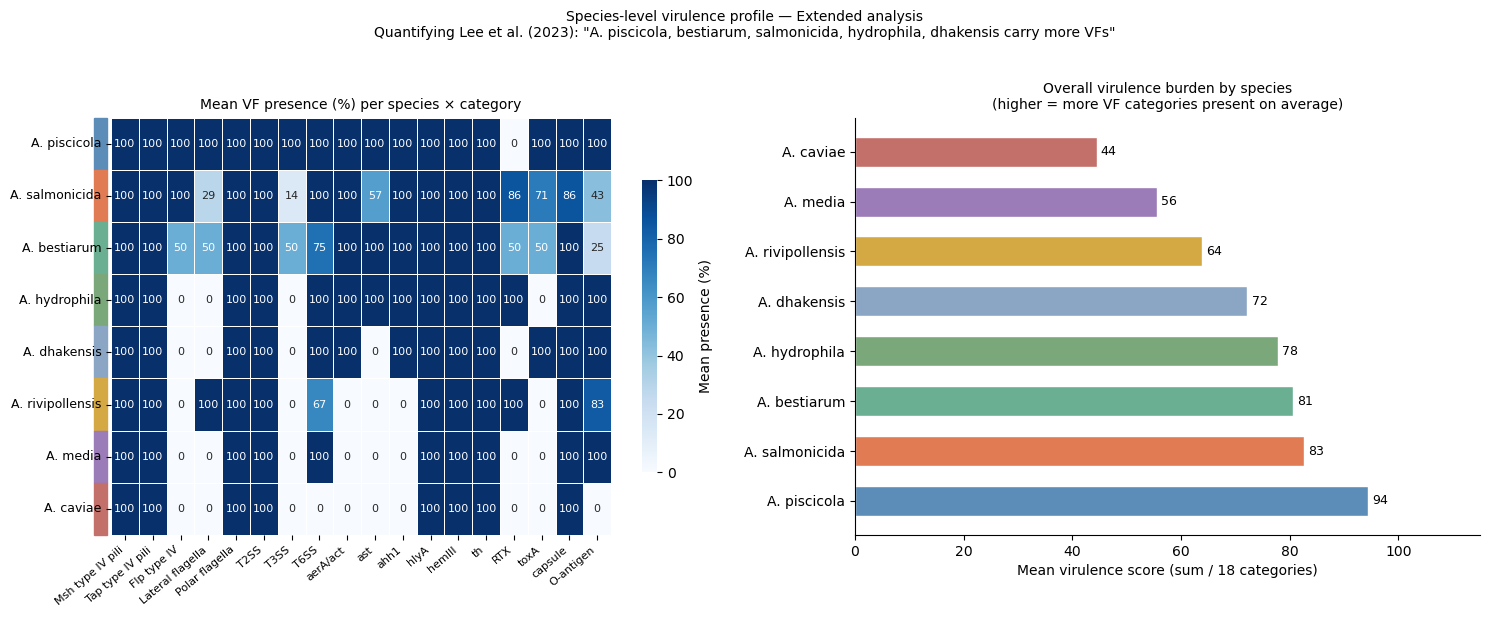

Saved: fig_species_virulence.png


In [9]:
# ── mean VF presence per species × category (isolates only) ───
vf_iso = vf_isolates.copy()
vf_iso['species'] = [species_map.get(s, 'Unknown') for s in vf_iso.index]

species_vf = (
    vf_iso.groupby('species')[list(vf.columns)]
    .mean()
    .mul(100)
    .round(1)
)

# species order: high-virulence → low-virulence (by total score)
species_total = species_vf.sum(axis=1).sort_values(ascending=False)
species_vf = species_vf.loc[species_total.index]

print('Mean VF presence (%) per species:')
print(species_vf.to_string())

# ── radar chart — species VF profile ─────────────────────────
# group by functional category for cleaner radar
group_order = ['Adherence', 'Motility', 'Secretion', 'Toxin', 'Immune evasion']

group_vf = {}
for grp in group_order:
    cats = [c for c, g in category_group.items() if g == grp]
    group_vf[grp] = species_vf[cats].mean(axis=1)
species_radar = pd.DataFrame(group_vf)

# ── plot: grouped bar per functional category ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: species × VF category heatmap
sp_colors = [species_palette.get(sp, '#CCCCCC') for sp in species_vf.index]

sns.heatmap(
    species_vf,
    ax=axes[0],
    cmap='Blues',
    vmin=0, vmax=100,
    annot=True, fmt='.0f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Mean presence (%)', 'shrink': 0.7}
)

# species color bar
for i, sp in enumerate(species_vf.index):
    axes[0].add_patch(plt.Rectangle(
        (-0.6, i), 0.45, 1,
        color=species_palette.get(sp, '#CCCCCC'),
        clip_on=False, transform=axes[0].transData
    ))

axes[0].set_xticklabels(
    axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8
)
axes[0].set_yticklabels(
    axes[0].get_yticklabels(), rotation=0, fontsize=9
)
axes[0].set_title('Mean VF presence (%) per species × category', fontsize=10)
axes[0].set_ylabel('')

# right: total VF score per species (bar)
total_scores = species_vf.sum(axis=1) / 18   # normalised 0–100
sp_bar_colors = [species_palette.get(sp, '#CCCCCC')
                 for sp in total_scores.index]
bars = axes[1].barh(total_scores.index, total_scores.values,
                    color=sp_bar_colors, edgecolor='white', height=0.6)
axes[1].bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
axes[1].set_xlabel('Mean virulence score (sum / 18 categories)', fontsize=10)
axes[1].set_title('Overall virulence burden by species\n'
                  '(higher = more VF categories present on average)',
                  fontsize=10)
axes[1].set_xlim(0, 115)
sns.despine(ax=axes[1])

plt.suptitle(
    'Species-level virulence profile — Extended analysis\n'
    'Quantifying Lee et al. (2023): "A. piscicola, bestiarum, salmonicida, '
    'hydrophila, dhakensis carry more VFs"',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig(PROC / 'fig_species_virulence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_species_virulence.png')

In [10]:
# ── save species VF summary ───────────────────────────────────
species_vf.to_csv(PROC / 'species_virulence_profile.csv')
print('species_virulence_profile.csv saved')
print()
print('=== Files saved this notebook ===')
outputs = [
    'fig3_virulence_heatmap.png',
    'fig_virulence_scores.png',
    'fig_vf_prevalence.png',
    'fig_species_virulence.png',
    'virulence_scores.csv',
    'species_virulence_profile.csv',
]
for f in outputs:
    path = PROC / f
    exists = '✓' if path.exists() else '✗'
    print(f'  {exists} {f}')

species_virulence_profile.csv saved

=== Files saved this notebook ===
  ✓ fig3_virulence_heatmap.png
  ✓ fig_virulence_scores.png
  ✓ fig_vf_prevalence.png
  ✓ fig_species_virulence.png
  ✓ virulence_scores.csv
  ✓ species_virulence_profile.csv
